In [1]:
from diffusers import DiffusionPipeline  # noqa: E402
import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import gc
from torchvision import transforms
import numpy as np
from PIL import Image
import open_clip
import pandas as pd


tmpdir = '/home/qzhao9/code/sd_ft_lora/diffuusers/diffusers/examples/text_to_image/sd-kvasir-model-lora/checkpoint-5000'

pipe = DiffusionPipeline.from_pretrained(
"CompVis/stable-diffusion-v1-4", safety_checker=None, device_map='cuda'
)
pipe.load_lora_weights(tmpdir)
print('Model Loaded to ', pipe.device)

# Load a CLIP model for the CLIP score calculation
vit_model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
vit_model.half().to('cuda')
vit_model.eval()  # model in train mode by default, impacts some models with BatchNorm or stochastic depth active
vit_tokenizer = open_clip.get_tokenizer('ViT-B-32')
print('OPEN CLIP model loaded')



Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

Model Loaded to  cuda:0
OPEN CLIP model loaded


In [8]:
from PIL import ImageDraw, ImageFont

eval_cfg = {
    'num_inference_steps': 20,
    'guidance_scale': 7.5,
    'height': 512,
    'width': 512,
    'generator': torch.Generator(device='cuda').manual_seed(56),
    'negative_prompt':'Do NOT generate technical overlays on the image, avoid timestamp, patient data placeholders or green scope orientation graphic on the image.'
    }

eval_prompts = [
    "A detailed endoscopic image showing inflamed mucosa with ulcerations and erythema, indicative of active ulcerative colitis.",
    "An endoscopic view of the colon revealing multiple polyps of varying sizes, some with a sessile appearance, requiring biopsy for histopathological evaluation.",
    "A high-resolution endoscopic image capturing a bleeding gastric ulcer with visible vessel, surrounded by edematous and erythematous tissue." 
    "endoscopic image of the colon with realistic mucosal texture and lighting",
    "endoscopic view of the colonic lumen with natural illumination and shadows",
    "wide-angle endoscopic view of colon interior"  
]



test_data_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv'
test_pd = pd.read_csv(test_data_file).to_dict(orient='records')

save_path_generated = '/home/qzhao9/datasets/kvasir-dataset/test_generated_images_8.8'

    

# def clip_score(
#  image = preprocess(Image.open(f'{save_path_generated}/{record["img"]}')).unsqueeze(0).to('cuda')
#  text = tokenizer([record['desc']]).to('cuda')

#  with torch.no_grad(), torch.autocast("cuda"):
#      image_features = model.encode_image(image)
#      text_features = model.encode_text(text)
#      image_features /= image_features.norm(dim=-1, keepdim=True)
#      text_features /= text_features.norm(dim=-1, keepdim=True)

#      clip = (100.0 * image_features @ text_features.T).item()
#      scores.append(clip)

     
# print("CLIP Score:", np.mean(scores, axis=0))


def transform_img(imgs, scores):
    transformed = []
    t = transforms.ToTensor()
    for i,image_pil in enumerate(imgs):
        # image_pil = Image.fromarray(image_array)
        draw = ImageDraw.Draw(image_pil)
    
        # Load font
        font_path = '/usr/share/fonts/truetype/ubuntu/UbuntuSans[wdth,wght].ttf'
        try:
            font = ImageFont.truetype(font_path, 50) if font_path else ImageFont.load_default()
        except IOError:
            print(f"Could not load font from {font_path}. Using default font.")
            font = ImageFont.load_default()
    
        # Add text
        draw.text((5,5), f'CLIP Score: {scores[i]:.2f}', font=font, fill=(255,0,0))
        # print(t(np.array(image_pil)))
        transformed.append(t(image_pil))
    return transformed
    
def generate(pipe, prompts, eval_cfg, numbers=1, save_path=None):
    # pipe.unet.eval()
    images = []
    clip_scores = []
    for _ in range(numbers):
        for i, prompt in enumerate(prompts):
            result = pipe(prompt, **eval_cfg ).images
            image = result[0]
            images.append(image)

            # CLIP Score
            with torch.no_grad(), torch.autocast("cuda"):
                image = preprocess(image).unsqueeze(0).to('cuda')
                text = vit_tokenizer([prompt]).to('cuda')
                text_features = vit_model.encode_text(text)
                image_features = vit_model.encode_image(image)
                image_features /= image_features.norm(dim=-1, keepdim=True)
                text_features /= text_features.norm(dim=-1, keepdim=True)
                clip = (100.0 * image_features @ text_features.T).item()
                clip_scores.append(clip)
                
            
            
    grid = vutils.make_grid(transform_img(images, clip_scores), nrow=3) #numbers
    plt.figure(figsize=(5*3,5*3)) #(5*numbers,5*len(prompts)
    plt.axis('off')
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    if save_path:
        plt.savefig(save_path, dpi=600)
    plt.show()


In [33]:
# !fc-list

/usr/share/fonts/truetype/dejavu/DejaVuSerif-Bold.ttf: DejaVu Serif:style=Bold
/usr/share/fonts/truetype/noto/NotoSansThai-Regular.ttf: Noto Sans Thai:style=Regular
/usr/share/fonts/truetype/noto/NotoSansModi-Regular.ttf: Noto Sans Modi:style=Regular
/usr/share/fonts/opentype/urw-base35/URWBookman-LightItalic.otf: URW Bookman:style=Light Italic
/usr/share/fonts/truetype/noto/NotoSansPahawhHmong-Regular.ttf: Noto Sans Pahawh Hmong:style=Regular
/usr/share/fonts/truetype/noto/NotoSerifYezidi-Bold.ttf: Noto Serif Yezidi:style=Bold
/usr/share/fonts/opentype/urw-base35/URWBookman-Light.otf: URW Bookman:style=Light
/usr/share/fonts/truetype/noto/NotoSansOldNorthArabian-Regular.ttf: Noto Sans Old North Arabian,Noto Sans OldNorArab:style=Regular
/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf: DejaVu Sans Mono:style=Book
/usr/share/fonts/truetype/noto/NotoSansCypriot-Regular.ttf: Noto Sans Cypriot:style=Regular
/usr/share/fonts/truetype/ubuntu/Ubuntu-Italic[wdth,wght].ttf: Ubuntu:style=Ita

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['.']


  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['.']


  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['.']


...

  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['.']


  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['.']


  0%|          | 0/20 [00:00<?, ?it/s]

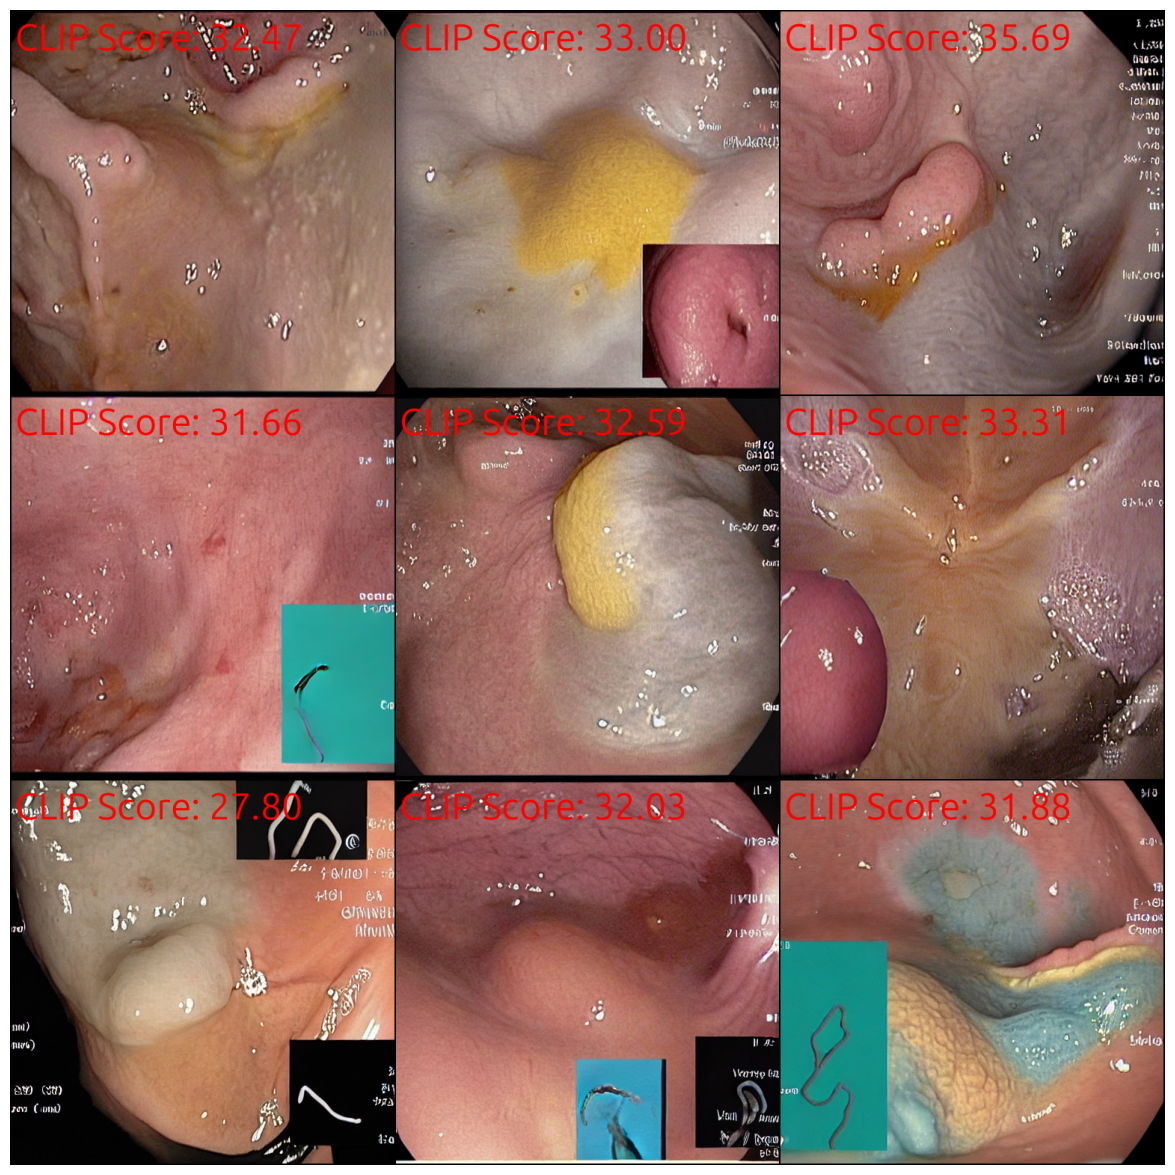

In [14]:
generate(pipe, 
         [
             #'Generate images depicting an uncommon presentation of inflammatory bowel disease characterized by patchy ulcerations and abnormal mucosal texture.',
             # "An adenoma polyp with a lobulated surface and irregular vascular pattern, suggestive of high-grade dysplasia, located in the sigmoid colon.",
             # "Close-up endoscopic view of a 15mm+ giant inflammatory pseudopolyp in the colon. The polyp has a lobulated, moss-like texture with a healthy, non-bleeding surface. The vascular pattern of the underlying colonic wall is visible and regular, signifying the absence of active acute severe ulcerative colitis."
             # "An endoscopic view inside a human colon showing multiple giant post-inflammatory pseudopolyps (PIPs). The polyps are large, fleshy, finger-like (filiform) projections exceeding 15mm, some forming thin mucosal bridges across the lumen. The background intestinal wall appears pale and healed."
             # 'High-definition colonoscopy image of acute severe ulcerative colitis showing continuous circumferential inflammation beginning at the rectum, with diffuse erythema, complete loss of vascular pattern, spontaneous mucosal bleeding, and multiple deep ulcerations extending into the transverse colon. No skip lesions. Clinical severity corresponds to Mayo score 3.'
             # "Colonoscopy image of quiescent ulcerative colitis with pale mucosa and preserved vascular pattern, containing multiple elongated, finger-like post-inflammatory pseudopolyps (10–20 mm) in the descending colon. No active ulceration, no contact bleeding, and no dysplastic features."
             # "Colonoscopy image showing moderate left-sided ulcerative colitis with continuous erythema, mucosal edema, granularity, and superficial ulcerations limited to the rectum and sigmoid colon, with a sharp transition to normal mucosa proximally. Partial loss of vascular pattern, no deep ulcers, consistent with Mayo subscore 2."
             # "High-definition chromoendoscopy image in a patient with long-standing ulcerative colitis, showing a subtle flat, slightly elevated lesion with irregular borders and abnormal pit pattern in the transverse colon after dye spraying. Surrounding mucosa shows scarring and post-inflammatory changes. Lesion appearance consistent with low-grade dysplasia."
             "Colonoscopy image of a patient with known ulcerative colitis showing diffuse mucosal erythema, edema, and shallow ulcerations, with patchy yellow-white adherent exudates on the mucosal surface. Background inflammation is continuous, raising diagnostic consideration of ulcerative colitis flare with superimposed Clostridioides difficile infection."
         ], 
         eval_cfg,
         9,'/home/qzhao9/code/scenario_3_0.png')

In [2]:
import pandas as pd
import os
from PIL import Image

test_data_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv'
test_pd = pd.read_csv(test_data_file)
save_path_generated = '/home/qzhao9/datasets/kvasir-dataset/test_generated_images_8.8'
save_path_test = '/home/qzhao9/datasets/kvasir-dataset/test_images_8.8'
image_root = r'/home/qzhao9/datasets/kvasir-dataset'

if os.path.exists(save_path_generated) is False:
    os.makedirs(save_path_generated)
if os.path.exists(save_path_test) is False:
    os.makedirs(save_path_test)

def generate_test_img(pipe, dataset, eval_cfg, save_path_generated,save_path_test):
    # pipe.unet.eval()
    for i, record in enumerate(dataset[:]):
        result = pipe(record['desc'], **eval_cfg ).images
        image = result[0].convert('RGB')
        image.save(f'{save_path_generated}/{record["img"]}')
        test_img = Image.open(f'{image_root}/{record["category"]}/{record["img"]}').resize((eval_cfg['width'], eval_cfg['height'])).convert('RGB')
        test_img.save(f'{save_path_test}/{record["img"]}')
        

test_pd.head(100)

,category,img,desc
0,dyed-lifted-polyps,77d0ed0b-1aab-42d7-a7e6-e8d668291101.jpg,The image showcases a colon endoscopic view of...
1,dyed-lifted-polyps,0da9c916-f978-4cc6-b1a2-e424c980bf17.jpg,The image shows a colon endoscopic view of a l...
2,dyed-lifted-polyps,427bbdc5-d1b5-4ee3-afeb-c8091c9cb10f.jpg,The image shows a close-up of a colon during a...
3,dyed-lifted-polyps,5f3d6ed3-dca1-4fb0-a0e3-fd53fffa4cff.jpg,The image shows a close-up view of a colon dur...
4,dyed-lifted-polyps,82530ab9-0162-4f11-8e80-686f7e7b92c6.jpg,The image shows a close-up of a colon during a...
...,...,...,...
95,dyed-lifted-polyps,201df7f0-cd85-4af9-9012-bf4f70792444.jpg,"The image is an endoscopic view of a colon, fo..."
96,dyed-lifted-polyps,e50eaaeb-2617-49c0-a8b0-a1264b42bed2.jpg,The image shows a close-up view of a colon dur...
97,dyed-lifted-polyps,71471ed0-0e15-42a2-ae16-336f597265af.jpg,"The image is an endoscopic view of a colon, fo..."
98,dyed-lifted-polyps,8a7fb665-446a-44cb-8098-7a8b46b15ffc.jpg,The image shows a close-up of a colon during a...


In [4]:
generate_test_img(pipe, test_pd.to_dict(orient='records'), eval_cfg, save_path_generated=save_path_generated, save_path_test=save_path_test)

Token indices sequence length is longer than the specified maximum sequence length for this model (85 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: [', and a green scope orientation graphic .']


  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['.']


  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['lays on the image , including a timestamp , patient data placeholders , and a green scope orientation graphic .']


...

  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["placeholders , and a reflection of the endoscope 's light source ."]


  0%|          | 0/20 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['image , including a timestamp , patient data placeholders , and a green scope orientation graphic .']


  0%|          | 0/20 [00:00<?, ?it/s]

# calculate Measurement Metrics

In [5]:
import torch_fidelity

metrics_dict = torch_fidelity.calculate_metrics(
    input1=save_path_generated, 
    input2=save_path_test, 
    cuda=True, 
    isc=True, 
    fid=True, 
    kid=True, 
    prc=True, 
    verbose=False,
    kid_subset_size=1000
)

In [7]:
print(metrics_dict)

{'inception_score_mean': 2.9879511823187936, 'inception_score_std': 0.22025091403716085, 'frechet_inception_distance': 112.68199690825566, 'kernel_inception_distance_mean': 0.08788257360458374, 'kernel_inception_distance_std': 1.1609295677127697e-07}


In [33]:
import open_clip
open_clip.list_pretrained()

[('RN50', 'openai'),
 ('RN50', 'yfcc15m'),
 ('RN50', 'cc12m'),
 ('RN101', 'openai'),
 ('RN101', 'yfcc15m'),
 ('RN50x4', 'openai'),
 ('RN50x16', 'openai'),
 ('RN50x64', 'openai'),
 ('ViT-B-32', 'openai'),
 ('ViT-B-32', 'laion400m_e31'),
 ('ViT-B-32', 'laion400m_e32'),
 ('ViT-B-32', 'laion2b_e16'),
 ('ViT-B-32', 'laion2b_s34b_b79k'),
 ('ViT-B-32', 'datacomp_xl_s13b_b90k'),
 ('ViT-B-32', 'datacomp_m_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_clip_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_laion_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_image_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_text_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_basic_s128m_b4k'),
 ('ViT-B-32', 'commonpool_m_s128m_b4k'),
 ('ViT-B-32', 'datacomp_s_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_clip_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_laion_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_image_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_text_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_basic_s13m_b4k'),
 ('ViT-B-32', 'commonpool_s_s13m_b4k'),
 ('ViT-

In [7]:
import torch
from PIL import Image
import open_clip
import numpy as np
import pandas as pd

test_data_file = '/home/qzhao9/datasets/kvasir-dataset/image_description_test_8.8.csv'
test_pd = pd.read_csv(test_data_file).to_dict(orient='records')

save_path_generated = '/home/qzhao9/datasets/kvasir-dataset/test_generated_images_8.8'

    
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='openai')
model.half().to('cuda')
model.eval()  # model in train mode by default, impacts some models with BatchNorm or stochastic depth active
tokenizer = open_clip.get_tokenizer('ViT-B-32')

scores = []
for record in test_pd[:0]:
     image = preprocess(Image.open(f'{save_path_generated}/{record["img"]}')).unsqueeze(0).to('cuda')
     text = tokenizer([record['desc']]).to('cuda')

     with torch.no_grad(), torch.autocast("cuda"):
         image_features = model.encode_image(image)
         text_features = model.encode_text(text)
         image_features /= image_features.norm(dim=-1, keepdim=True)
         text_features /= text_features.norm(dim=-1, keepdim=True)

         clip = (100.0 * image_features @ text_features.T).item()
         scores.append(clip)

     
print("CLIP Score:", np.mean(scores, axis=0))



/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP Score: nan


/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/qzhao9/miniconda3/envs/rag/lib/python3.11/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
